<a href="https://colab.research.google.com/github/am610/AGN_SURD/blob/main/3_SURDS_AGN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Revealing Causal Structure in AGN Reverberation Mapping with Information Decomposition (SURD)

Reverberation mapping of active galactic nuclei (AGN) has traditionally relied on cross-correlation techniques to infer time delays between continuum and emission-line variability, providing constraints on the geometry of the broad-line region. However, these methods are inherently limited to pairwise correlations and cannot disentangle the relative contributions of multiple, potentially redundant or synergistic driving signals across different wavebands.

In this work, we introduce an information-theoretic framework based on Synergistic–Unique–Redundant Decomposition (SURD) to analyse multi-band AGN light curves and quantify the causal structure underlying their variability. By decomposing the mutual information between future emission-line flux and present continuum signals into unique, redundant, and synergistic components, we construct a model-independent map of information flow across wavelengths and time lags.

We validate the method using controlled synthetic systems representing single-driver, redundant-proxy, and genuinely synergistic scenarios, demonstrating that SURD robustly recovers the expected information structure in each case. We then apply this framework to AGN reverberation mapping data, resampling irregularly sampled light curves onto a uniform grid and performing a systematic lag scan to identify the dominant channels of information transfer.

Our results show that traditional lag estimates can be complemented by a richer characterisation of variability, revealing whether different continuum bands provide independent constraints on the emission-line response or simply trace a common hidden driver. This approach opens a new avenue for probing the physical origin of AGN variability and for testing multi-component accretion and reprocessing models beyond standard correlation-based analyses.

In [2]:
!git clone https://github.com/Computational-Turbulence-Group/SURD.git
import sys
!{sys.executable} -m pip install --no-cache-dir pymp-pypi

Cloning into 'SURD'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 126 (delta 20), reused 15 (delta 15), pack-reused 101 (from 1)
Receiving objects: 100% (126/126), 56.65 MiB | 35.39 MiB/s, done.
Resolving deltas: 100% (52/52), done.
  Preparing metadata (setup.py) ... done
  Created wheel for pymp-pypi: filename=pymp_pypi-0.5.0-py3-none-any.whl size=10314 sha256=32a7cbc556470847b696d65e9397115fafadfb85dc6ebf79476047141593fc17
  Stored in directory: /tmp/pip-ephem-wheel-cache-aiamazap/wheels/49/3c/be/bc41032d07354230b2bd851a07ea4bdc20d0e461d2beccad0e
Successfully built pymp-pypi


Core SURD AGN starter script
----------------------------------------
SURD CAUSALITY FOR SIGNAL 1
    Redundant (R):
        (1, 2)      : 0.0000
        (1, 3)      : 0.1381
        (2, 3)      : 0.0000
        (1, 2, 3)   : 0.6194
    Unique (U):
        (1,)        : 0.0708
        (2,)        : 0.0000
        (3,)        : 0.0000
    Synergystic (S):
        (1, 2)      : 0.0353
        (1, 3)      : 0.0341
        (2, 3)      : 0.0224
        (1, 2, 3)   : 0.0800
    Information Leak: 50.41%


SURD CAUSALITY FOR SIGNAL 2
    Redundant (R):
        (1, 2)      : 0.0018
        (1, 3)      : 0.1220
        (2, 3)      : 0.0000
        (1, 2, 3)   : 0.6537
    Unique (U):
        (1,)        : 0.0402
        (2,)        : 0.0018
        (3,)        : 0.0005
    Synergystic (S):
        (1, 2)      : 0.0290
        (1, 3)      : 0.0283
        (2, 3)      : 0.0286
        (1, 2, 3)   : 0.0941
    Information Leak: 61.53%


SURD CAUSALITY FOR SIGNAL 3
    Redundant (R):
        (1, 2) 

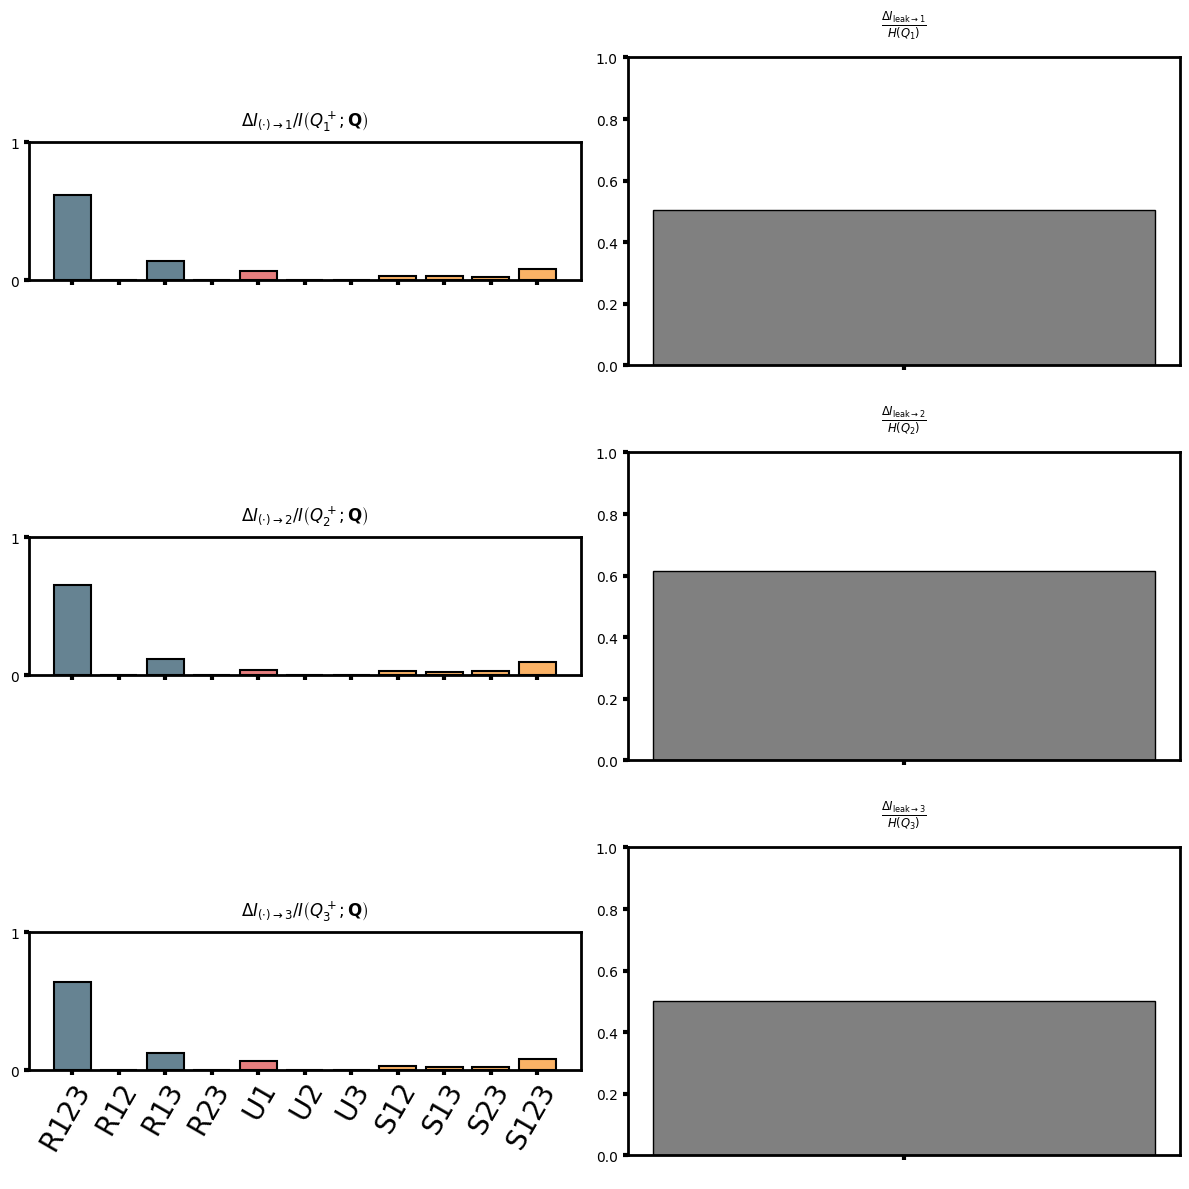

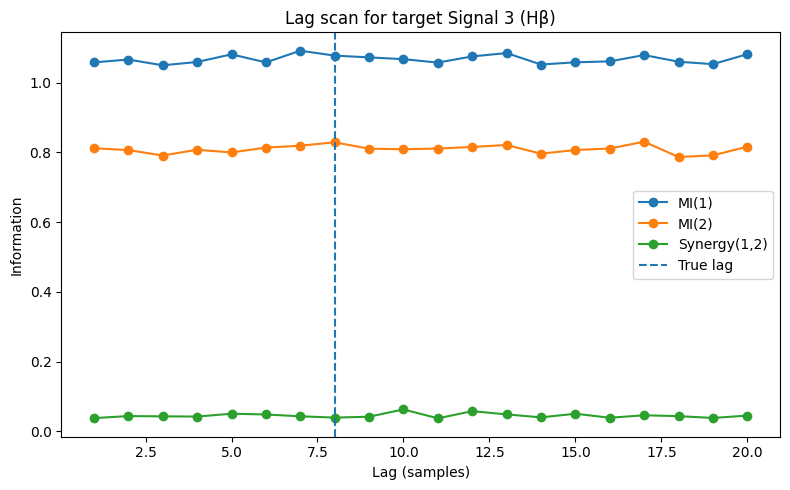

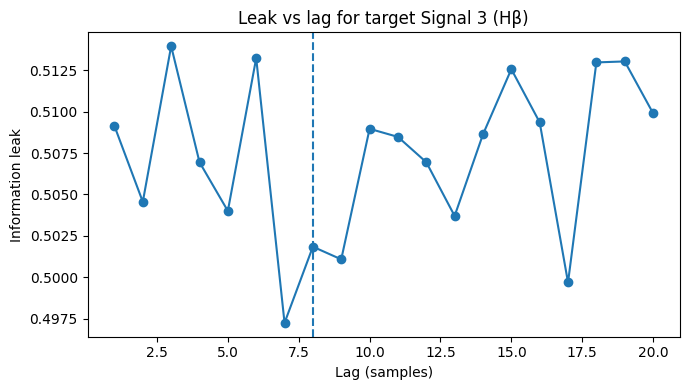


Interpretation note:
If you use a random-walk hidden driver, the information curves often look broad rather than sharply peaked, because the driver has strong temporal autocorrelation.
For a cleaner lag-localisation test, rerun with random_walk_driver=False in make_synthetic_agn().

Done.


In [3]:
"""
SURD AGN starter script
=======================

Purpose
-------
This script collects the main steps testing
the SURD repository for an AGN-style reverberation mapping toy problem.

What this script does
---------------------
1. Assumes the SURD repository has already been cloned in Colab or locally.
2. Adds the SURD `utils` directory to Python's import path.
3. Imports the core SURD modules.
4. Builds a synthetic AGN-like time-series data set:
      - hidden UV driver
      - optical continuum proxy
      - X-ray continuum proxy
      - delayed Hβ emission-line response
5. Runs the SURD decomposition for a single lag.
6. Scans across many lags and stores metrics for the final target signal.
7. Provides a helper that returns results for *all* target signals.
8. Shows how to run one of the built-in analytic benchmark systems.

Important notes
---------------
- This script intentionally avoids `transport_map.py`, because that path
  requires the optional `mpart` / MParT dependency.
- The SURD `run()` helper prints and plots results for all targets, but it
  returns only the decomposition for the *last* target processed. For clean
  analysis, this script includes a custom `run_collect()` wrapper.
- The lag parameter `nlag` is in samples, not physical days.

Expected environment
--------------------
This script is written for the same setup that worked in Colab:
    pip install pymp-pypi numpy scipy matplotlib pandas scikit-learn

and then:
    sys.path.append("/content/SURD/utils")

Adapt the SURD_UTILS_PATH below if your cloned repo lives elsewhere.
"""

from __future__ import annotations

import sys
from pathlib import Path
from typing import Dict, Any

import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# 1. Configure path to SURD repo utilities
# =============================================================================
# Change this if your SURD clone is somewhere else.
SURD_UTILS_PATH = Path("/content/SURD/utils")

if not SURD_UTILS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find SURD utils directory at {SURD_UTILS_PATH}. "
        "Update SURD_UTILS_PATH to match your local or Colab clone."
    )

sys.path.append(str(SURD_UTILS_PATH))

# Core SURD imports
import surd            # noqa: E402
import it_tools        # noqa: E402  # imported for completeness / inspection
import analytic_eqs    # noqa: E402


# =============================================================================
# 2. Utility helpers
# =============================================================================
def zscore(x: np.ndarray) -> np.ndarray:
    """
    Standardise an array to zero mean and unit variance.

    Parameters
    ----------
    x : np.ndarray
        Input array.

    Returns
    -------
    np.ndarray
        Standardised array.
    """
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / np.std(x)


def run_collect(
    X: np.ndarray,
    nvars: int,
    nlag: int,
    nbins: int,
    axs: np.ndarray | None = None,
    print_results: bool = False,
) -> Dict[int, Dict[str, Any]]:
    """
    Run SURD for each target signal and return a clean dictionary of results.

    Why this helper exists
    ----------------------
    The repo's `surd.run(...)` function loops over all targets and plots all of
    them, but returns only the decomposition of the final target in the loop.
    For analysis, it is much more useful to collect results for every target.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (nvars, ntimes). Each row is one signal.
    nvars : int
        Number of signals.
    nlag : int
        Lag in samples.
    nbins : int
        Number of histogram bins used by np.histogramdd.
    axs : np.ndarray or None
        Optional axes array of shape (nvars, 2) for SURD plotting.
    print_results : bool
        If True, print the SURD decomposition for each target.

    Returns
    -------
    dict
        Dictionary keyed by target index, with values containing:
            - "I_R"
            - "I_S"
            - "MI"
            - "info_leak"
    """
    results = {}

    for i in range(nvars):
        # Future of target i versus present/past of all variables
        Y = np.vstack([X[i, nlag:], X[:, :-nlag]])

        # Multi-dimensional histogram approximation to the joint distribution
        hist, _ = np.histogramdd(Y.T, nbins)

        # SURD decomposition
        I_R, I_S, MI, info_leak = surd.surd(hist)

        results[i] = {
            "I_R": I_R,
            "I_S": I_S,
            "MI": MI,
            "info_leak": info_leak,
        }

        if print_results:
            print(f"\nSURD CAUSALITY FOR TARGET SIGNAL {i + 1}")
            surd.nice_print(I_R, I_S, MI, info_leak)

        if axs is not None:
            surd.plot(I_R, I_S, info_leak, axs[i, :], nvars, threshold=-0.01)

    return results


# =============================================================================
# 3. Synthetic AGN-style toy data
# =============================================================================
def make_synthetic_agn(
    N: int = 3000,
    tau: int = 8,
    seed: int = 42,
    random_walk_driver: bool = True,
) -> np.ndarray:
    """
    Build a synthetic AGN-like system with three signals.

    Signal definitions
    ------------------
    1. optical continuum: noisy proxy for hidden UV driver
    2. X-ray continuum:  noisy proxy for hidden UV driver
    3. Hβ emission line: delayed response to the UV driver

    Parameters
    ----------
    N : int
        Number of time samples.
    tau : int
        Reverberation lag in samples.
    seed : int
        Random seed for reproducibility.
    random_walk_driver : bool
        If True, use a random-walk hidden driver (long memory).
        If False, use white noise hidden driver (sharper lag localisation).

    Returns
    -------
    np.ndarray
        Stacked array X of shape (3, N).
    """
    rng = np.random.default_rng(seed)

    # Hidden UV driver
    if random_walk_driver:
        uv = np.cumsum(rng.normal(0, 0.15, N))
    else:
        uv = rng.normal(0, 1.0, N)
    uv = zscore(uv)

    # Two observed continuum proxies
    optical = 0.9 * uv + 0.25 * rng.normal(size=N)
    xray = 0.7 * uv + 0.35 * rng.normal(size=N)

    # Delayed broad-line response
    hbeta = np.zeros(N)
    hbeta[tau:] = 0.8 * uv[:-tau] + 0.25 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.25 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# =============================================================================
# 4. Demonstration: single-lag SURD run
# =============================================================================
def demo_single_lag() -> None:
    """
    Run a single-lag SURD decomposition on the synthetic AGN toy system.
    """
    tau = 8
    X = make_synthetic_agn(N=3000, tau=tau, seed=42, random_walk_driver=True)
    nvars = X.shape[0]

    fig, axs = plt.subplots(nvars, 2, figsize=(12, 4 * nvars), squeeze=False)

    # This is the repo's built-in wrapper.
    # It prints and plots all targets, but returns only the final target result.
    surd.run(X=X, nvars=nvars, nlag=tau, nbins=8, axs=axs)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 5. Demonstration: lag scan for target Signal 3
# =============================================================================
def demo_lag_scan() -> None:
    """
    Scan over lag values and track selected information measures.

    We focus on the final target (Signal 3, Hβ) by using run_collect().
    """
    tau_true = 8
    X = make_synthetic_agn(N=3000, tau=tau_true, seed=42, random_walk_driver=True)
    nvars = X.shape[0]

    lags = np.arange(1, 21)
    mi1, mi2, syn12, leak = [], [], [], []

    for lag in lags:
        results = run_collect(X=X, nvars=nvars, nlag=lag, nbins=8)

        # Target index 2 = Signal 3 in 1-based human counting
        res = results[2]

        # Notes:
        # MI keys refer to variable combinations in the SURD histogram indexing.
        # We keep the same convention used during the Colab exploration.
        mi1.append(res["MI"].get((1,), np.nan))
        mi2.append(res["MI"].get((2,), np.nan))
        syn12.append(res["I_S"].get((1, 2), np.nan))
        leak.append(res["info_leak"])

    plt.figure(figsize=(8, 5))
    plt.plot(lags, mi1, marker="o", label="MI(1)")
    plt.plot(lags, mi2, marker="o", label="MI(2)")
    plt.plot(lags, syn12, marker="o", label="Synergy(1,2)")
    plt.axvline(tau_true, linestyle="--", label="True lag")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Information")
    plt.title("Lag scan for target Signal 3 (Hβ)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(lags, leak, marker="o")
    plt.axvline(tau_true, linestyle="--")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Information leak")
    plt.title("Leak vs lag for target Signal 3 (Hβ)")
    plt.tight_layout()
    plt.show()

    print("\nInterpretation note:")
    print(
        "If you use a random-walk hidden driver, the information curves often "
        "look broad rather than sharply peaked, because the driver has strong "
        "temporal autocorrelation."
    )
    print(
        "For a cleaner lag-localisation test, rerun with "
        "random_walk_driver=False in make_synthetic_agn()."
    )


# =============================================================================
# 6. Demonstration: compare random-walk vs white-noise hidden driver
# =============================================================================
def demo_driver_comparison() -> None:
    """
    Compare how lag localisation changes when the hidden driver has long memory
    versus no memory.
    """
    tau_true = 8
    lags = np.arange(1, 21)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)

    for ax, use_rw, title in zip(
        axs[0],
        [True, False],
        ["Random-walk driver", "White-noise driver"],
        strict=True,
    ):
        X = make_synthetic_agn(
            N=3000,
            tau=tau_true,
            seed=42,
            random_walk_driver=use_rw,
        )

        leak = []
        for lag in lags:
            results = run_collect(X=X, nvars=3, nlag=lag, nbins=8)
            leak.append(results[2]["info_leak"])

        ax.plot(lags, leak, marker="o")
        ax.axvline(tau_true, linestyle="--")
        ax.set_xlabel("Lag (samples)")
        ax.set_ylabel("Information leak")
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 7. Demonstration: built-in analytic benchmark
# =============================================================================
def demo_analytic_benchmark() -> None:
    """
    Run one of the built-in synthetic benchmark systems from analytic_eqs.

    Available functions discovered during the Colab session:
        - confounder
        - mediator
        - redundant_collider
        - synergistic_collider
    """
    q1, q2, q3 = analytic_eqs.confounder(3000)
    X = np.vstack([q1, q2, q3])

    fig, axs = plt.subplots(3, 2, figsize=(10, 12), squeeze=False)
    surd.run(X=X, nvars=3, nlag=1, nbins=8, axs=axs)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 8. Main execution block
# =============================================================================
if __name__ == "__main__":
    print("Core SURD AGN starter script")
    print("-" * 40)

    # Uncomment whichever demos you want to run.

    # 1) Single-lag toy example
    demo_single_lag()

    # 2) Lag scan for the Hβ target
    demo_lag_scan()

    # 3) Compare long-memory and short-memory hidden drivers
    # demo_driver_comparison()

    # 4) Run a built-in benchmark motif
    # demo_analytic_benchmark()

    print("\nDone.")


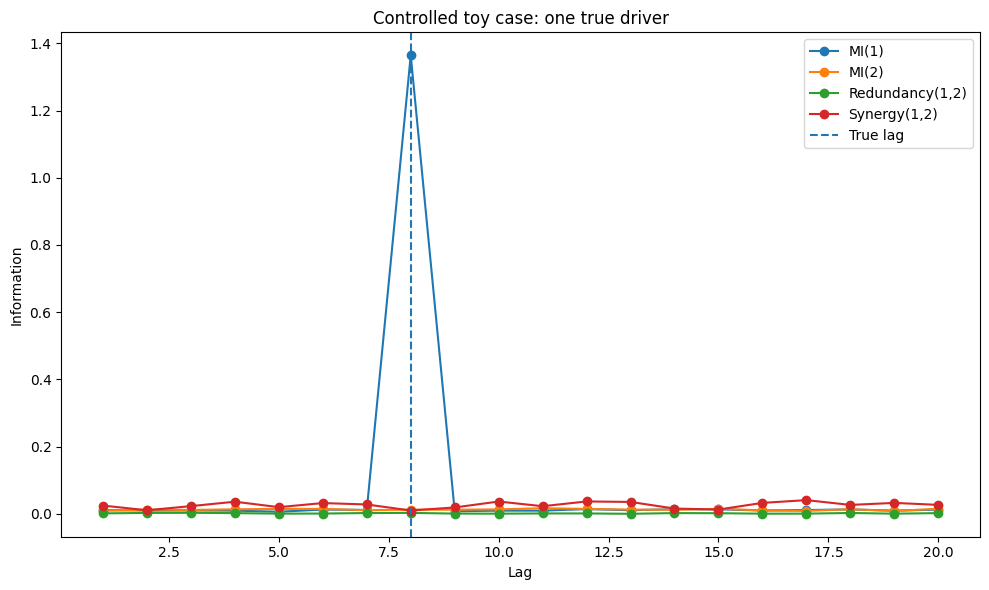

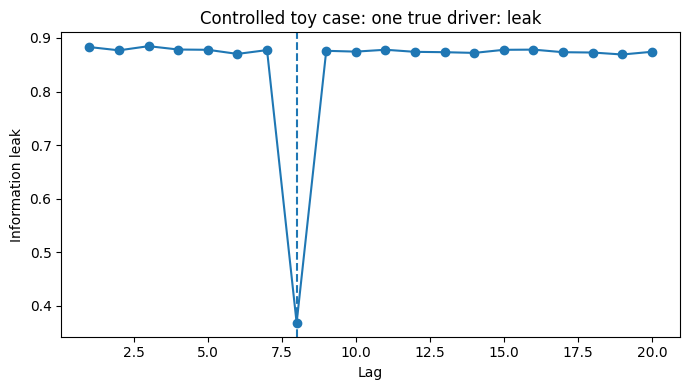

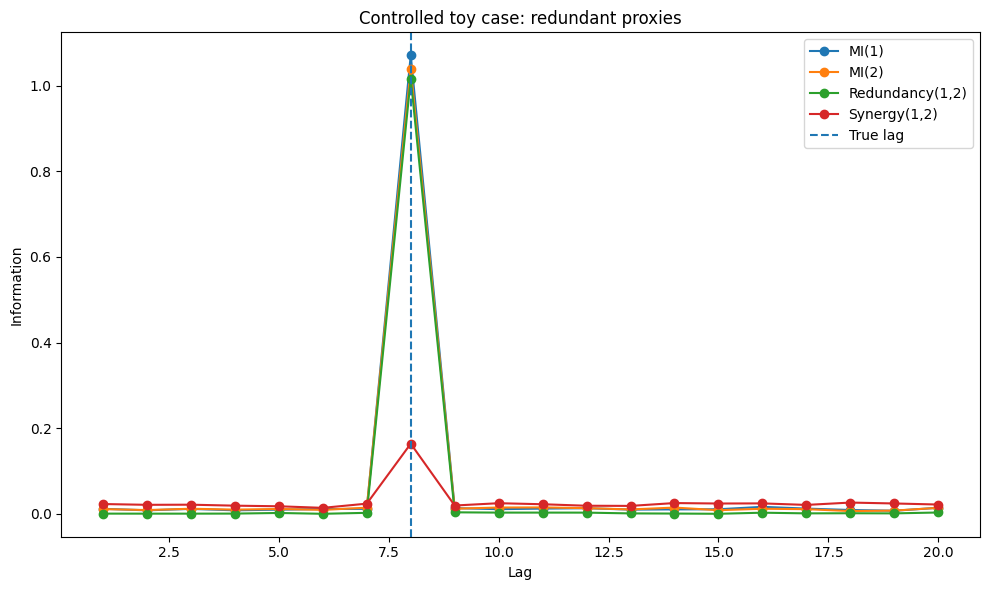

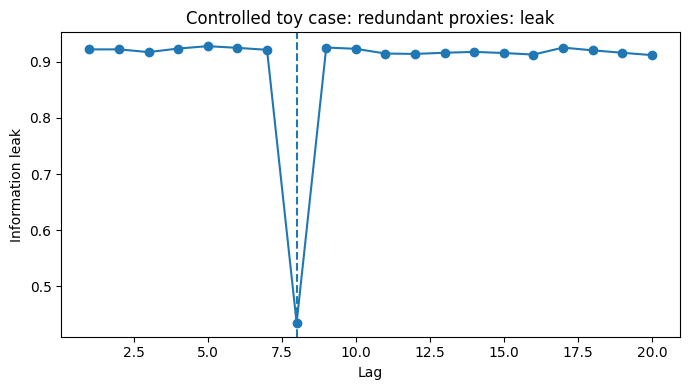

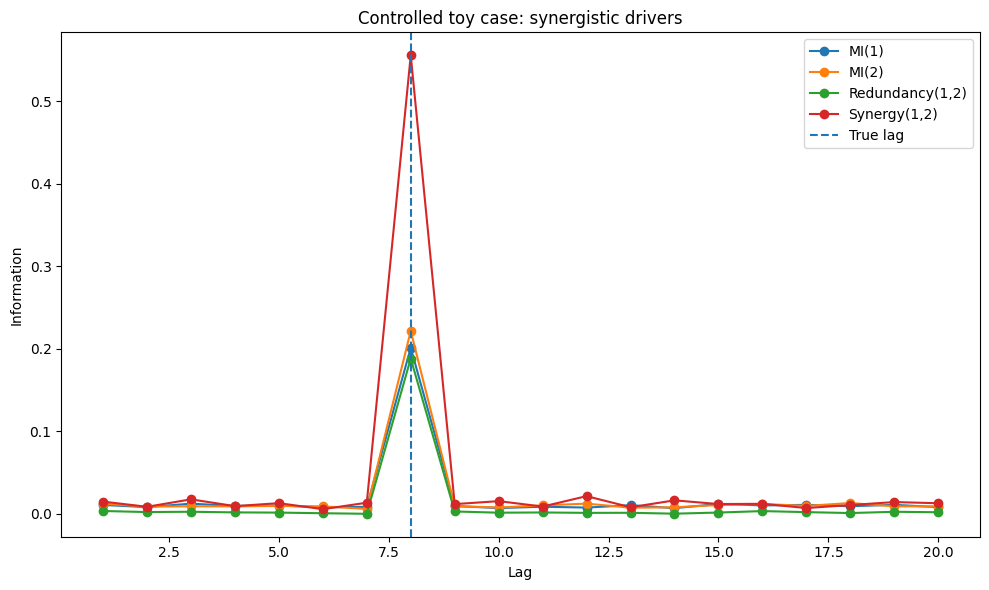

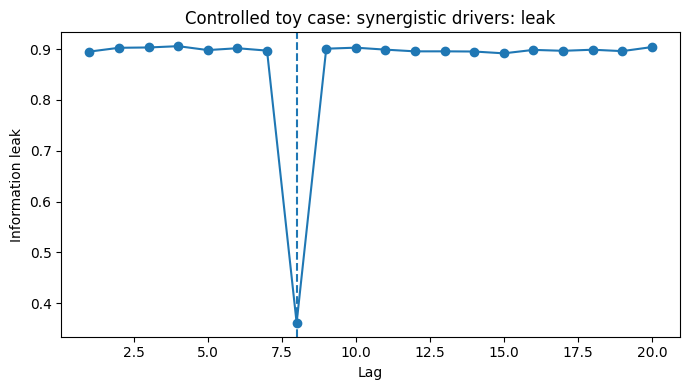

Summary at the true lag:
------------------------------------------------------------
One true driver     : MI1=1.3646, MI2=0.0126, R12=0.0028, S12=0.0099, Leak=0.3685
Redundant proxies   : MI1=1.0708, MI2=1.0383, R12=1.0163, S12=0.1640, Leak=0.4346
Synergistic drivers : MI1=0.2014, MI2=0.2218, R12=0.1884, S12=0.5559, Leak=0.3615


'\n# ----- Example placeholders: replace with your real AGN arrays -----\ntime_opt = np.array([...], dtype=float)\nflux_opt = np.array([...], dtype=float)\n\ntime_xray = np.array([...], dtype=float)\nflux_xray = np.array([...], dtype=float)\n\ntime_hbeta = np.array([...], dtype=float)\nflux_hbeta = np.array([...], dtype=float)\n\n# Choose a uniform grid spacing in the same units as your time arrays.\n# Example: if times are in days, dt = 1.0 means 1-day cadence.\ndt = 1.0\n\n# Prepare the three aligned standardised bands\ngrid, X_real = prepare_agn_timeseries(\n    time_opt, flux_opt,\n    time_xray, flux_xray,\n    time_hbeta, flux_hbeta,\n    dt=dt\n)\n\n# Visual sanity check of the interpolated / standardised signals\nplt.figure(figsize=(12, 5))\nplt.plot(grid, X_real[0], label=\'Optical\')\nplt.plot(grid, X_real[1], label=\'X-ray\')\nplt.plot(grid, X_real[2], label=\'Hβ\')\nplt.xlabel(\'Time\')\nplt.ylabel(\'Standardised flux\')\nplt.title(\'Prepared AGN time series on common grid\

In [4]:
# =============================================================================
# 9. Controlled toy cases + real AGN preprocessing helpers
# =============================================================================
#
# This cell extends the original SURD AGN starter workflow with:
#
#   A) Controlled toy cases
#      1. One true driver
#      2. Redundant proxies
#      3. Genuinely synergistic drivers
#
#   B) A reusable lag-scan helper for target Signal 3
#
#   C) A plotting helper for lag-scan outputs
#
#   D) Simple real-AGN preprocessing utilities
#      1. resample to a uniform time grid
#      2. standardise each band
#      3. stack into X = np.vstack([...])
#
#   E) Example execution blocks for both toy data and real AGN data
#
# Assumptions
# -----------
# This cell assumes the earlier notebook/script has already defined:
#   - np
#   - plt
#   - zscore(...)
#   - run_collect(...)
#
# In the SURD setup we used:
#   - row 0 = optical continuum
#   - row 1 = X-ray continuum
#   - row 2 = Hβ emission line
#
# and target Signal 3 corresponds to index 2 in Python.
# =============================================================================


# -----------------------------------------------------------------------------
# A1. Controlled toy case: one true driver
# -----------------------------------------------------------------------------
# Physical idea:
#   - Hβ responds only to the optical continuum after a lag tau
#   - X-ray is unrelated noise
#
# Expected SURD behaviour:
#   - optical should show strong unique information near the true lag
#   - X-ray should show very little unique information
#   - redundancy and synergy should be small
# -----------------------------------------------------------------------------
def make_case_one_true_driver(N=3000, tau=8, seed=1):
    rng = np.random.default_rng(seed)

    optical = rng.normal(size=N)
    xray = rng.normal(size=N)   # unrelated noise

    hbeta = np.zeros(N)
    hbeta[tau:] = 0.9 * optical[:-tau] + 0.2 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.2 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# A2. Controlled toy case: redundant proxies
# -----------------------------------------------------------------------------
# Physical idea:
#   - optical and X-ray are both noisy proxies of a hidden UV driver
#   - Hβ responds to that hidden UV driver after a lag tau
#
# Expected SURD behaviour:
#   - redundancy should be elevated
#   - both observed bands can appear informative
#   - some information leak can remain because the true UV driver is hidden
#
# The random_walk option is useful to study long-memory drivers, which often
# produce broader lag curves instead of sharply localised lag peaks.
# -----------------------------------------------------------------------------
def make_case_redundant_proxies(N=3000, tau=8, seed=2, random_walk=False):
    rng = np.random.default_rng(seed)

    if random_walk:
        uv = np.cumsum(rng.normal(0, 0.15, N))
    else:
        uv = rng.normal(size=N)

    uv = zscore(uv)

    optical = 0.9 * uv + 0.25 * rng.normal(size=N)
    xray = 0.8 * uv + 0.25 * rng.normal(size=N)

    hbeta = np.zeros(N)
    hbeta[tau:] = 0.85 * uv[:-tau] + 0.2 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.2 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# A3. Controlled toy case: genuinely synergistic drivers
# -----------------------------------------------------------------------------
# Physical idea:
#   - Hβ depends on a nonlinear combination of optical and X-ray
#   - neither optical nor X-ray alone is enough
#   - both together matter
#
# Expected SURD behaviour:
#   - synergy should be noticeably larger
#   - individual-band information may not fully explain the target
# -----------------------------------------------------------------------------
def make_case_synergy(N=3000, tau=8, seed=3):
    rng = np.random.default_rng(seed)

    optical = rng.normal(size=N)
    xray = rng.normal(size=N)

    hbeta = np.zeros(N)
    signal = optical[:-tau] * xray[:-tau]   # nonlinear joint driver
    hbeta[tau:] = signal + 0.25 * rng.normal(size=N - tau)
    hbeta[:tau] = 0.25 * rng.normal(size=tau)

    optical = zscore(optical)
    xray = zscore(xray)
    hbeta = zscore(hbeta)

    return np.vstack([optical, xray, hbeta])


# -----------------------------------------------------------------------------
# B. Reusable lag-scan helper for target Signal 3 (Hβ)
# -----------------------------------------------------------------------------
# This helper scans a list/array of lags and stores selected SURD quantities
# for the target row corresponding to the emission-line signal.
#
# Stored metrics:
#   - info_leak
#   - MI(1), MI(2)
#   - U(1), U(2)  [approx. from I_R singletons as used in repo printout]
#   - R(1,2)
#   - S(1,2)
# -----------------------------------------------------------------------------
def lag_scan_target3(X, lags, nbins=8):
    metrics = {
        "lag": [],
        "info_leak": [],
        "MI1": [],
        "MI2": [],
        "U1": [],
        "U2": [],
        "R12": [],
        "S12": [],
    }

    for lag in lags:
        results = run_collect(X=X, nvars=3, nlag=lag, nbins=nbins)
        res = results[2]   # target index 2 = Signal 3 (Hβ)

        metrics["lag"].append(lag)
        metrics["info_leak"].append(res["info_leak"])
        metrics["MI1"].append(res["MI"].get((1,), np.nan))
        metrics["MI2"].append(res["MI"].get((2,), np.nan))
        metrics["U1"].append(res["I_R"].get((1,), np.nan))
        metrics["U2"].append(res["I_R"].get((2,), np.nan))
        metrics["R12"].append(res["I_R"].get((1, 2), np.nan))
        metrics["S12"].append(res["I_S"].get((1, 2), np.nan))

    return metrics


# -----------------------------------------------------------------------------
# C. Plotting helper for lag-scan results
# -----------------------------------------------------------------------------
# Produces:
#   1. Information curves vs lag
#   2. Information leak vs lag
#
# Optionally mark the true lag with a vertical dashed line.
# -----------------------------------------------------------------------------
def plot_lag_metrics(metrics, true_tau=None, title="Lag scan for target Signal 3"):
    lags = np.array(metrics["lag"])

    plt.figure(figsize=(10, 6))
    plt.plot(lags, metrics["MI1"], marker="o", label="MI(1)")
    plt.plot(lags, metrics["MI2"], marker="o", label="MI(2)")
    plt.plot(lags, metrics["R12"], marker="o", label="Redundancy(1,2)")
    plt.plot(lags, metrics["S12"], marker="o", label="Synergy(1,2)")
    if true_tau is not None:
        plt.axvline(true_tau, linestyle="--", label="True lag")
    plt.xlabel("Lag")
    plt.ylabel("Information")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(lags, metrics["info_leak"], marker="o")
    if true_tau is not None:
        plt.axvline(true_tau, linestyle="--")
    plt.xlabel("Lag")
    plt.ylabel("Information leak")
    plt.title(f"{title}: leak")
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# D1. Simple interpolation onto a uniform time grid
# -----------------------------------------------------------------------------
# Why this is needed:
#   The SURD workflow here expects aligned time-series samples.
#   Real AGN light curves are often irregularly sampled, so as a first-pass
#   prototype we interpolate each band onto a common uniform grid.
#
# Important caution:
#   Interpolation can introduce artificial structure. It is acceptable for an
#   initial prototype, but later you may want a more careful uneven-sampling
#   treatment or at least sensitivity tests with different grid spacings.
# -----------------------------------------------------------------------------
def resample_to_uniform_grid(times, values, tmin=None, tmax=None, dt=1.0):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)

    if tmin is None:
        tmin = np.min(times)
    if tmax is None:
        tmax = np.max(times)

    grid = np.arange(tmin, tmax + dt, dt)
    vals = np.interp(grid, times, values)
    return grid, vals


# -----------------------------------------------------------------------------
# D2. Prepare real AGN time series for SURD
# -----------------------------------------------------------------------------
# Inputs:
#   - time_opt, flux_opt   : optical continuum light curve
#   - time_xray, flux_xray : X-ray continuum light curve
#   - time_hb, flux_hb     : Hβ emission-line light curve
#
# Steps:
#   1. restrict to the common overlapping time range
#   2. interpolate each series onto a shared uniform grid
#   3. z-score each band
#   4. stack into X = np.vstack([optical, xray, hbeta])
#
# Returns:
#   - grid : common time grid
#   - X    : stacked standardised data for SURD
# -----------------------------------------------------------------------------
def prepare_agn_timeseries(time_opt, flux_opt, time_xray, flux_xray, time_hb, flux_hb, dt=1.0):
    tmin = max(np.min(time_opt), np.min(time_xray), np.min(time_hb))
    tmax = min(np.max(time_opt), np.max(time_xray), np.max(time_hb))

    grid, opt = resample_to_uniform_grid(time_opt, flux_opt, tmin=tmin, tmax=tmax, dt=dt)
    _, xray = resample_to_uniform_grid(time_xray, flux_xray, tmin=tmin, tmax=tmax, dt=dt)
    _, hb = resample_to_uniform_grid(time_hb, flux_hb, tmin=tmin, tmax=tmax, dt=dt)

    opt = zscore(opt)
    xray = zscore(xray)
    hb = zscore(hb)

    X = np.vstack([opt, xray, hb])
    return grid, X


# -----------------------------------------------------------------------------
# E1. Example: run all three toy benchmark cases
# -----------------------------------------------------------------------------
# These are the first things to run before trusting any real-data result.
# They tell you whether SURD is qualitatively recovering the expected pattern:
#
#   - one true driver      -> strong unique info from optical
#   - redundant proxies    -> elevated redundancy
#   - synergistic drivers  -> elevated synergy
# -----------------------------------------------------------------------------
lags = np.arange(1, 21)
tau = 8

# --- Case 1: one true driver ---
X_true = make_case_one_true_driver(N=3000, tau=tau, seed=1)
m_true = lag_scan_target3(X_true, lags, nbins=8)
plot_lag_metrics(m_true, true_tau=tau, title="Controlled toy case: one true driver")

# --- Case 2: redundant proxies ---
X_red = make_case_redundant_proxies(N=3000, tau=tau, seed=2, random_walk=False)
m_red = lag_scan_target3(X_red, lags, nbins=8)
plot_lag_metrics(m_red, true_tau=tau, title="Controlled toy case: redundant proxies")

# --- Case 3: genuinely synergistic drivers ---
X_syn = make_case_synergy(N=3000, tau=tau, seed=3)
m_syn = lag_scan_target3(X_syn, lags, nbins=8)
plot_lag_metrics(m_syn, true_tau=tau, title="Controlled toy case: synergistic drivers")


# -----------------------------------------------------------------------------
# E2. Example: compare the three toy cases at the true lag
# -----------------------------------------------------------------------------
# This gives a quick numerical comparison of the main information terms.
# -----------------------------------------------------------------------------
true_lag_index = np.where(lags == tau)[0][0]

print("Summary at the true lag:")
print("-" * 60)
print(f"One true driver     : MI1={m_true['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_true['MI2'][true_lag_index]:.4f}, "
      f"R12={m_true['R12'][true_lag_index]:.4f}, "
      f"S12={m_true['S12'][true_lag_index]:.4f}, "
      f"Leak={m_true['info_leak'][true_lag_index]:.4f}")

print(f"Redundant proxies   : MI1={m_red['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_red['MI2'][true_lag_index]:.4f}, "
      f"R12={m_red['R12'][true_lag_index]:.4f}, "
      f"S12={m_red['S12'][true_lag_index]:.4f}, "
      f"Leak={m_red['info_leak'][true_lag_index]:.4f}")

print(f"Synergistic drivers : MI1={m_syn['MI1'][true_lag_index]:.4f}, "
      f"MI2={m_syn['MI2'][true_lag_index]:.4f}, "
      f"R12={m_syn['R12'][true_lag_index]:.4f}, "
      f"S12={m_syn['S12'][true_lag_index]:.4f}, "
      f"Leak={m_syn['info_leak'][true_lag_index]:.4f}")


# -----------------------------------------------------------------------------
# E3. Template for real AGN data
# -----------------------------------------------------------------------------
# Replace the placeholder arrays below with your actual light-curve data.
#
# Example expected variables:
#   time_opt, flux_opt
#   time_xray, flux_xray
#   time_hbeta, flux_hbeta
#
# Then:
#   1. resample to a uniform cadence
#   2. stack into X_real
#   3. scan over lags
#   4. inspect unique/redundant/synergistic information for the Hβ target
#
# To use this section, uncomment it and replace the placeholders.
# -----------------------------------------------------------------------------
"""
# ----- Example placeholders: replace with your real AGN arrays -----
time_opt = np.array([...], dtype=float)
flux_opt = np.array([...], dtype=float)

time_xray = np.array([...], dtype=float)
flux_xray = np.array([...], dtype=float)

time_hbeta = np.array([...], dtype=float)
flux_hbeta = np.array([...], dtype=float)

# Choose a uniform grid spacing in the same units as your time arrays.
# Example: if times are in days, dt = 1.0 means 1-day cadence.
dt = 1.0

# Prepare the three aligned standardised bands
grid, X_real = prepare_agn_timeseries(
    time_opt, flux_opt,
    time_xray, flux_xray,
    time_hbeta, flux_hbeta,
    dt=dt
)

# Visual sanity check of the interpolated / standardised signals
plt.figure(figsize=(12, 5))
plt.plot(grid, X_real[0], label='Optical')
plt.plot(grid, X_real[1], label='X-ray')
plt.plot(grid, X_real[2], label='Hβ')
plt.xlabel('Time')
plt.ylabel('Standardised flux')
plt.title('Prepared AGN time series on common grid')
plt.legend()
plt.tight_layout()
plt.show()

# Define lag range in samples.
# If dt = 2 days and you want to scan to 100 days, use:
# lags = np.arange(1, int(100 / dt) + 1)
lags_real = np.arange(1, 51)

# Run SURD lag scan on the emission-line target
metrics_real = lag_scan_target3(X_real, lags_real, nbins=8)

# Plot the results
plot_lag_metrics(metrics_real, true_tau=None, title='Real AGN lag scan')

# Optional: convert lag samples to physical time
lag_days = dt * np.array(metrics_real['lag'])

# Example extra plot with physical units
plt.figure(figsize=(10, 6))
plt.plot(lag_days, metrics_real["MI1"], marker="o", label="MI(1)")
plt.plot(lag_days, metrics_real["MI2"], marker="o", label="MI(2)")
plt.plot(lag_days, metrics_real["R12"], marker="o", label="Redundancy(1,2)")
plt.plot(lag_days, metrics_real["S12"], marker="o", label="Synergy(1,2)")
plt.xlabel("Lag (days)")
plt.ylabel("Information")
plt.title("Real AGN lag scan in physical units")
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation:
#   - strong U1 / MI1 near some lag: optical carries predictive line information
#   - strong U2 / MI2 near some lag: X-ray carries predictive line information
#   - strong R12: both bands may be redundant proxies for a hidden driver
#   - strong S12: combining both bands helps more than either alone
#   - high leak: substantial line variability remains unexplained by observed bands
"""
# =============================================================================
# End of extension cell
# =============================================================================

In [9]:
# SDSS
# Install astroquery
